# 투빅스 25&26기 5주차 정규세션 1교시 Computer Vision 과제
---

## Imagenette로 직접 구현하는 ResNet-18 & Vision Transformer

안녕하세요 여러분? 정규세션 CV 파트 담당하게된 정상현입니다. 다들 5주차 정규세션 정말 수고 많으셨습니다. 과제도 열심히 준비했으니, 여러분께 도움이 될 수 있길 바랍니다.

이번 과제에서는 아래의 실습을 해보려합니다

1. **ResNet-18을 직접 구현**하며 Residual Block과 Skip Connection을 코드로 확인합니다.
2. **Vision Transformer(ViT)를 직접 구현**하며 Patch Embedding, CLS Token, Positional Embedding, Transformer Encoder가 실제 코드에서 어떻게 연결되는지 확인합니다.
3. 두 모델을 동일한 조건에서 학습하고 성능과 학습 특성을 비교합니다.
4. 마지막으로 학습 데이터의 양을 바꿔보며, CNN과 ViT의 데이터 효율 차이를 관찰합니다.

이번 과제의 목적은 단순히 “어느 모델의 정확도가 더 높은가?”를 확인하는 것이 아닙니다.  
강의에서 배운 내용들이 실제 학습 결과에서 어떻게 나타나는지 본인의 출력값을 근거로 설명해보는 것이 핵심입니다.

###GPU 사용을 권장합니다. Colab에서는 `런타임 → 런타임 유형 변경 → T4 GPU`를 선택해주세요.



## 제출물

1. 빈칸을 모두 채우고 전부 실행한 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션에 Q.6.2의 실험 결과 및 모델 비교에 대한 본인의 답변을 옮겨 적기


---

## 0. 환경 설정 — Library, Seed, Device

먼저 필요한 라이브러리를 불러오고 실험 환경을 고정해봅시다.

딥러닝 실험에는 가중치 초기화, 데이터 셔플, 데이터 분할 등 여러 곳에서 난수가 사용됩니다.  
따라서 같은 조건을 다시 실행했을 때 최대한 비슷한 결과를 얻을 수 있도록 Seed를 고정합니다.

또한 이미지 모델 학습은 CPU에서 매우 느리므로 GPU가 연결되어 있는지도 함께 확인해봅시다.

**코드의 빈칸을 채워주세요!**

In [1]:
# ── 기본 라이브러리 ─────────────────────────────────────────────
import os
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.datasets.utils import download_and_extract_archive

from sklearn.model_selection import train_test_split

# ── 0. 실험 재현성을 위한 Seed 설정 ─────────────────────────────
MY_SEED = 2004            # TODO : 본인이 원하는 시드를 입력하세요!

random.seed(2004)         # TODO
np.random.seed(2004)      # TODO
torch.manual_seed(2004)   # TODO

# GPU가 있으면 CUDA를, 없으면 CPU를 사용합니다.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CUDA 환경에서도 가능한 범위에서 재현성을 높입니다.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)

print("PyTorch version :", torch.__version__)
print("Device          :", DEVICE)
print("Seed            :", MY_SEED)

if DEVICE.type == "cpu":
    print("\n[주의] 현재 CPU 런타임입니다. 전체 학습은 매우 오래 걸릴 수 있습니다.")

PyTorch version : 2.11.0+cu128
Device          : cuda
Seed            : 2004


---
# 1. Imagenette 데이터 준비

## 1.1 Dataset 다운로드 및 확인

이번 과제에서는 **Imagenette 320px** 버전을 사용합니다. Imagenette는 ImageNet에서 10개 클래스를 추려 만든 이미지 분류 데이터셋입니다.

전체 ImageNet을 직접 학습하기에는 계산량이 너무 크기 때문에, 자연 이미지의 특성은 유지하면서도 비교적 가볍게 실험할 수 있는 Imagenette를 사용합니다.

아래 코드는 약 340MB의 압축 파일을 내려받고 `/content/data` 아래에 자동으로 압축을 해제합니다.  
이미 다운로드되어 있다면 다시 받지 않습니다.

**코드 채우기 없습니다!**

In [2]:
# ── Imagenette 다운로드 ──────────────────────────────────────────
DATA_ROOT = Path("/content/data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz"
IMAGENETTE_DIR = DATA_ROOT / "imagenette2-320"

if not IMAGENETTE_DIR.exists():
    print("Imagenette를 다운로드합니다...")
    download_and_extract_archive(
        url=IMAGENETTE_URL,
        download_root=str(DATA_ROOT),
        remove_finished=True,
    )
else:
    print("이미 다운로드된 Imagenette를 사용합니다.")

TRAIN_DIR = IMAGENETTE_DIR / "train"
TEST_DIR  = IMAGENETTE_DIR / "val"   # 공식 validation split은 이번 과제에서 최종 test로 사용합니다.

print("Train directory :", TRAIN_DIR)
print("Test directory  :", TEST_DIR)

Imagenette를 다운로드합니다...


100%|██████████| 342M/342M [00:08<00:00, 41.3MB/s]


Train directory : /content/data/imagenette2-320/train
Test directory  : /content/data/imagenette2-320/val


In [3]:
# ── Dataset의 기본 정보 확인 ────────────────────────────────────
# transform을 적용하지 않은 ImageFolder를 먼저 만들어
# 이미지 개수, 클래스, 라벨 분포만 확인합니다.
raw_train = datasets.ImageFolder(TRAIN_DIR)
raw_test  = datasets.ImageFolder(TEST_DIR)

# Imagenette의 폴더명은 ImageNet의 WordNet ID(WNID)입니다.
# 사람이 읽기 편하도록 실제 클래스 이름으로 매핑합니다.
WNID_TO_NAME = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}

CLASS_NAMES = [WNID_TO_NAME[c] for c in raw_train.classes]
NUM_CLASSES = len(CLASS_NAMES)

print("Train images :", len(raw_train))
print("Test images  :", len(raw_test))
print("Num classes  :", NUM_CLASSES)
print("Classes      :", CLASS_NAMES)

# 클래스별 샘플 수를 확인합니다.
train_targets = np.array(raw_train.targets)
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)

print("\n[Train class distribution]")
for i, count in enumerate(class_counts):
    print(f"{i:2d}. {CLASS_NAMES[i]:18s} : {count}")

Train images : 9469
Test images  : 3925
Num classes  : 10
Classes      : ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']

[Train class distribution]
 0. tench              : 963
 1. English springer   : 955
 2. cassette player    : 993
 3. chain saw          : 858
 4. church             : 941
 5. French horn        : 956
 6. garbage truck      : 961
 7. gas pump           : 931
 8. golf ball          : 951
 9. parachute          : 960


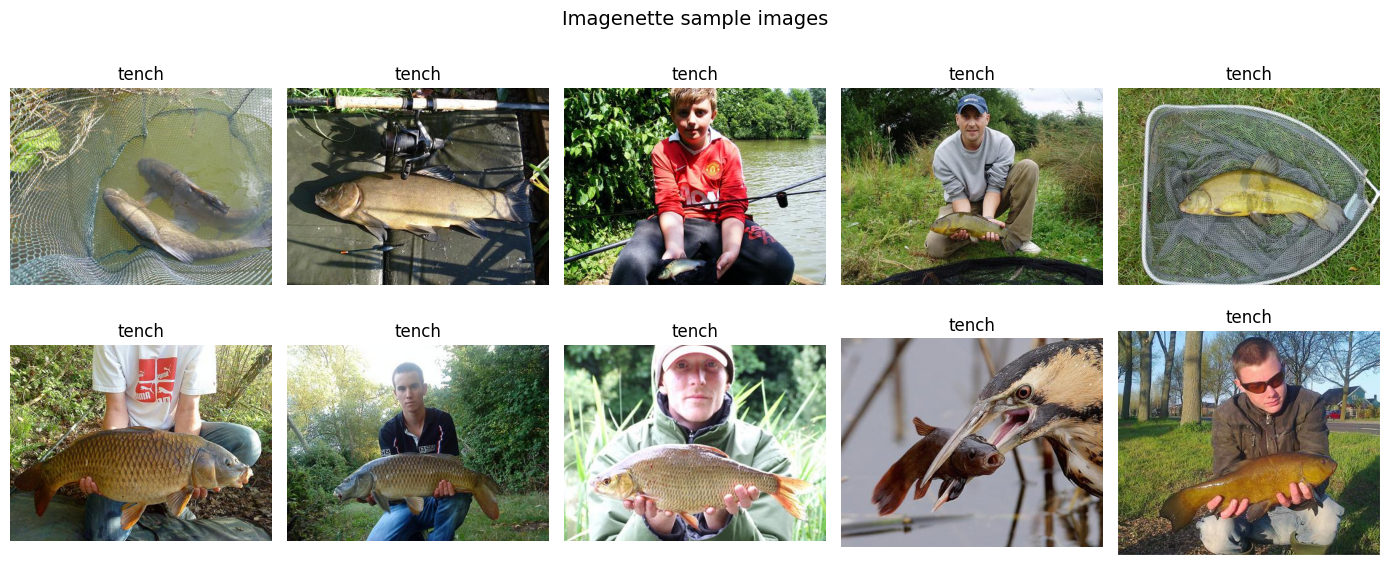

In [4]:
# ── 원본 이미지 직접 확인 ──────────────────────────────────────
# 모델을 학습하기 전에 실제 데이터가 어떻게 생겼는지 먼저 눈으로 확인해봅시다.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.ravel()):
    image, label = raw_train[i]
    ax.imshow(image)
    ax.set_title(CLASS_NAMES[label])
    ax.axis("off")

plt.suptitle("Imagenette sample images", fontsize=14)
plt.tight_layout()
plt.show()

###Q.1.1 데이터 살피기
1.  Train/Test에는 각각 몇장의 이미지가 들어있나요?
    
    A. Train images : 9469장, Test images  : 3925장이 있다.

2. 원본 이미지들의 가로·세로 크기는 모두 동일해 보이나요?

    A. 네 동일해보입니다 !


---
## 1.2 Train / Validation / Test 분리와 Image Transform

Imagenette에는 기본적으로 `train`과 `val` 폴더가 있습니다.

이번 과제에서는 다음과 같이 사용합니다.

- **Train**: 모델의 Weight를 실제로 업데이트하는 데이터
- **Validation**: 학습 중 모델을 비교하고 Best Epoch를 선택하는 데이터
- **Test**: 모든 비교가 끝난 뒤 최종 성능을 확인하는 데이터

따라서 원래 Imagenette의 `train`을 다시 **Train 80% / Validation 20%**로 나누고, 공식 `val` 폴더는 마지막 **Test set**으로 남겨두겠습니다.

또한 모델에 입력되는 이미지 크기는 `224 × 224`로 통일합니다.

Train에는 Random Crop과 Horizontal Flip을 적용하지만, Validation/Test에는 무작위 Augmentation을 사용하지 않습니다.  
평가할 때마다 이미지가 달라지면 모델 간 성능 비교 자체가 흔들릴 수 있기 때문입니다.



---
추가로 발표에서 정규화에 대해 다루지 않았기에 짧게 설명을 추가하겠습니다

Image Normalization

이미지의 Pixel 값은 모델에 입력하기 전 일정한 분포를 갖도록 정규화(Normalization) 할 수 있습니다.

각 Channel의 Pixel 값에 대해 다음과 같이 변환합니다.

$$ x_{\text{norm}} = \frac{x-\mu}{\sigma} $$
$\mu$ : 해당 Channel의 평균(Mean)

$\sigma$ : 해당 Channel의 표준편차(Standard Deviation)

RGB 이미지이므로 R, G, B Channel별로 각각 정규화합니다.

이번 과제에서는 ImageNet 계열에서 일반적으로 사용하는 Mean과 Std를 사용합니다.

**코드의 빈칸을 채워주세요!**

In [5]:
# ── ImageNet 계열에서 널리 사용하는 Normalize 값 ──────────────
IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Train에서는 매 epoch마다 조금씩 다른 이미지를 보도록 Data Augmentation을 적용합니다.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),   #TODO : 이미지 크기
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),                       #TODO : 정규화!
])

# Validation / Test는 항상 동일한 방식으로 평가합니다.
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),                            #TODO : 이미지 크기
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),                       #TODO : 정규화!
])

# 같은 원본 폴더를 사용하지만,
# Train용 Dataset에는 augmentation을, Validation용 Dataset에는 deterministic transform을 적용합니다.
train_aug_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
train_eval_dataset = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

# 원본 Train을 80:20으로 나눕니다.
# stratify를 사용해 Train/Validation의 클래스 비율을 비슷하게 유지합니다.
all_indices = np.arange(len(raw_train))

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=MY_SEED,
    stratify=train_targets,
)

print("Internal train :", len(train_indices))
print("Internal val   :", len(val_indices))
print("Final test     :", len(test_dataset))

Internal train : 7575
Internal val   : 1894
Final test     : 3925


In [6]:
# ── DataLoader 생성 ─────────────────────────────────────────────
BATCH_SIZE = 64
NUM_WORKERS = 2

train_dataset = Subset(train_aug_dataset, train_indices)
val_dataset   = Subset(train_eval_dataset, val_indices)

# DataLoader의 shuffle 순서도 Seed를 고정합니다.
train_generator = torch.Generator().manual_seed(MY_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    generator=train_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

# 한 Mini-batch의 Tensor Shape를 확인합니다.
images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Label example     :", labels[:10].tolist())

Image batch shape : torch.Size([64, 3, 224, 224])
Label batch shape : torch.Size([64])
Label example     : [2, 1, 0, 3, 1, 2, 5, 0, 3, 3]


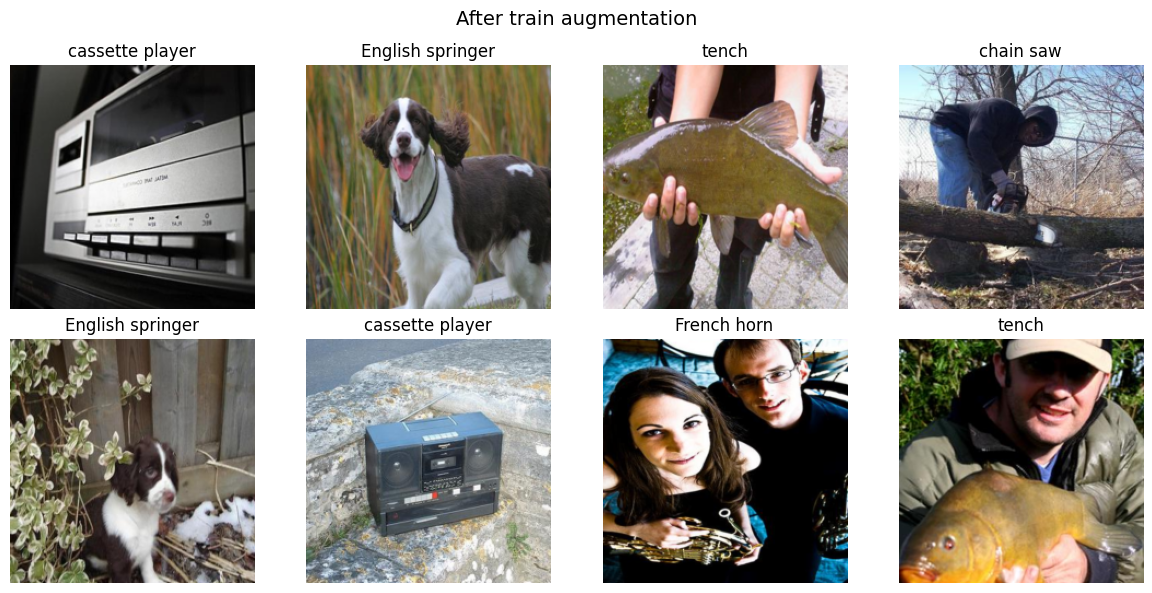

In [7]:
# ── Normalize된 이미지를 다시 화면에 표시하는 함수 ────────────
def denormalize(img_tensor):
    """Normalize된 (C,H,W) Tensor를 시각화 가능한 [0,1] 범위로 되돌립니다."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1)

# 실제 Train transform이 적용된 이미지도 확인해봅시다.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.ravel()):
    img = denormalize(images[i]).permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()])
    ax.axis("off")

plt.suptitle("After train augmentation", fontsize=14)
plt.tight_layout()
plt.show()

###Q.1.2 이미지의 전처리와 데이터 분할을 생각해봅시다

1. `images.shape`를 실제 출력값 그대로 적고, 각 차원이 무엇을 의미하는지 설명해주세요.

    A. torch.Size([64, 3, 224, 224])이다. images.shape의 실제 출력값은 torch.Size([64, 3, 224, 224])입니다. 각 차원은 순서대로 배치 크기(64), 채널 수(3 - RGB), 이미지 높이(224픽셀), 이미지 너비(224픽셀)를 의미합니다.

2. 이미지의 입력 크기를 동일하게 맞춰야하는 이유에 대해 설명해주세요.

    A. 딥러닝 모델의 Fully Connected Layer은 입력 벡터의 크기가 고정되어 있어야 올바른 가중치 연산이 가능하기 때문이다.

3. Train Set에서 Crop, Random Flip 하는 이유에 대해 설명해주세요.

    A. 학습할 때 모델이 위치나 방향에 치우치지 않고 이미지의 핵심 특징을 균일하게 학습하도록 도와준다. 그래서 데이터의 다양성을 늘려 과적합을 방지하고, 새로운 입력에 대한 일반화 성능을 높일 수 있다.

4. Val Set에서도 Train Set과 동일한 Augmentation을 적용하나요? 이유와 함께 설명해주세요.

    A. 적용하지 않는다. 왜냐하면 평가할 때마다 이미지가 달라지면 모델 간 성능 비교 자체가 흔들릴 수 있기 때문이다.

---

# 2. 공통 Training Pipeline 만들기

이제 ResNet과 ViT가 공통으로 사용할 학습 함수를 준비해봅시다.

두 모델은 구조는 다르지만, 학습 과정 자체는 동일합니다.

> `Mini-batch → Forward → Loss → Backward → Weight Update`

이번 비교에서는 두 모델 모두 같은 `CrossEntropyLoss`, `AdamW`, `CosineAnnealingLR`을 사용합니다.  
즉, 모든 모델에 가장 최적인 Hyperparameter를 찾는 것이 아니라 **가능한 한 동일한 학습 조건에서 구조적 차이를 관찰**하는 것이 목적입니다.

또한 Validation Accuracy가 가장 높았던 시점의 Weight를 저장하고, 학습이 끝난 뒤 그 Weight를 다시 불러옵니다.  
Test set은 아직 사용하지 않습니다.

**공통 코드기 때문에 따로 코드 빈칸 채우기는 없습니다!**

In [8]:
# ── 공통 Loss Function ──────────────────────────────────────────
# CrossEntropyLoss 내부에서 LogSoftmax가 처리되므로
# 모델 마지막에 Softmax를 직접 붙이지 않습니다.
criterion = nn.CrossEntropyLoss()


def count_parameters(model):
    """학습 가능한 Parameter의 총 개수를 반환합니다."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, optimizer, device):
    """한 epoch 동안 Train set으로 Weight를 업데이트합니다."""
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # 이전 Mini-batch에서 계산된 Gradient를 초기화합니다.
        optimizer.zero_grad()

        # Forward: 현재 Weight로 Class Logit을 예측합니다.
        logits = model(images)

        # 정답 Label과 비교하여 Loss를 계산합니다.
        loss = criterion(logits, labels)

        # Backward: 각 Parameter에 대한 Gradient를 계산합니다.
        loss.backward()

        # 계산된 Gradient를 이용해 Parameter를 업데이트합니다.
        optimizer.step()

        # Epoch 전체의 평균 Loss/Accuracy를 계산하기 위해 누적합니다.
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, device):
    """Validation/Test set에서는 Gradient를 계산하지 않고 Loss와 Accuracy만 측정합니다."""
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [9]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=3e-4,
    weight_decay=0.05,
    model_name="model",
):
    """
    하나의 모델을 학습하고 History와 요약 정보를 반환합니다.

    - Optimizer: AdamW
    - Scheduler: CosineAnnealingLR
    - Best Validation Accuracy가 갱신될 때 Weight를 저장
    - 학습 종료 후 Best Weight를 복원
    """
    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }

    best_val_acc = -1.0
    best_epoch = -1
    best_state = None

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, DEVICE
        )

        val_loss, val_acc = evaluate(
            model, val_loader, DEVICE
        )

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # Validation Accuracy가 가장 높았던 모델을 저장합니다.
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        scheduler.step()

        print(
            f"[{model_name}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
            f"lr {current_lr:.2e}"
        )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start_time

    # 가장 좋은 Validation Accuracy를 기록했던 Weight로 되돌립니다.
    model.load_state_dict(best_state)

    summary = {
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "total_time_sec": elapsed,
        "sec_per_epoch": elapsed / epochs,
    }

    print(
        f"\n[{model_name}] Best val acc = {best_val_acc:.4f} "
        f"(epoch {best_epoch}) | "
        f"total time = {elapsed/60:.1f} min"
    )

    return model, history, summary


def plot_history(history, title):
    """Train/Validation의 Loss와 Accuracy 학습 곡선을 출력합니다."""
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4.5))
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(epochs, history["train_acc"], label="train")
    plt.plot(epochs, history["val_acc"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

---
# 3. ResNet-18 직접 구현하기

이제 첫 번째 모델인 **ResNet-18**을 직접 구현해봅시다.

ResNet의 핵심은 전체 `H(x)`를 직접 학습하기보다 Residual Function `F(x)`를 학습하도록 만드는 것입니다.

Basic Residual Block은 다음과 같은 구조를 가집니다.

- Main Path: `Conv → BN → ReLU → Conv → BN`
- Shortcut Path: 입력 `x`를 그대로 전달
- 두 경로를 **Element-wise Addition**
- 마지막 ReLU

즉, Block의 핵심은 다음과 같습니다.

\[
y = F(x) + x
\]

다만 Feature Map의 Channel 수나 Spatial Size가 달라지는 지점에서는 `x`와 `F(x)`의 Shape가 달라 단순 Addition이 불가능합니다.  
이 경우 Shortcut Path에 **1×1 Convolution**을 사용해 Shape을 맞춥니다.

**코드 빈칸을 채워주세요!**

In [18]:
# ── ResNet BasicBlock ───────────────────────────────────────────
def conv3x3(in_channels, out_channels, stride=1):
    """3x3 Convolution 후 Spatial Size를 제어합니다."""
    return nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size=3,   #TODO : 다 적혀있다!
        stride=stride,
        padding=1,       #TODO : 사이즈를 유지하려면?
        bias=False,
    )


class BasicBlock(nn.Module):
    """
    ResNet-18 / ResNet-34에서 사용하는 Basic Residual Block입니다.

    Main path:
        3x3 Conv -> BN -> ReLU -> 3x3 Conv -> BN

    Shortcut:
        Shape가 같으면 Identity
        Shape가 다르면 1x1 Conv + BN

    마지막에 Main path와 Shortcut을 Addition합니다.
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = conv3x3(
            in_channels,
            out_channels,
            stride=stride,      # TODO: Block의 Downsampling 여부 반영
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = conv3x3(
            out_channels,
            out_channels,
            stride=1,      # TODO: 두 번째 Conv의 Stride : 두 번째 Conv는 Spatial Size를 고정해야 하므로 항상 stride=1 !!!!!
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 입력과 출력의 Shape가 같다면 그대로 전달합니다.
        self.shortcut = nn.Identity()

        # Spatial Size 또는 Channel 수가 달라지면
        # 1x1 Conv를 이용해 Shortcut의 Shape를 Main Path와 맞춥니다.
        if stride != 1 or in_channels != out_channels:   # TODO: 입/출력 사이즈가 다르려면?
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,       # TODO: Projection에 사용할 Kernel : 차원 맞춤용 Projection에는 1x1 Conv 사용!!!!
                    stride=stride,            # TODO
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        # Shortcut Path의 입력을 미리 저장합니다.
        identity = self.shortcut(x)

        # Main Path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Residual Connection의 핵심:
        # Feature를 Channel 방향으로 붙이는 것이 아니라 Element-wise Addition합니다.
        out = out + identity       #TODO

        out = self.relu(out)
        return out

In [19]:
# ── ResNet-18 전체 Architecture ─────────────────────────────────
class ResNet18(nn.Module):
    """
    ResNet-18 구조

    Stem:
        7x7 Conv -> BN -> ReLU -> MaxPool

    Residual Stages:
        [2, 2, 2, 2]개의 BasicBlock
        Channel: 64 -> 128 -> 256 -> 512

    Head:
        Global Average Pooling -> Fully Connected
    """

    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        # ── Stem ────────────────────────────────────────────────
        self.stem = nn.Sequential(
            nn.Conv2d(
                3,
                64,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1,
            ),
        )

        # ── Residual Stages ─────────────────────────────────────
        self.layer1 = self._make_layer(
            out_channels=64,
            blocks=2,
            stride=1,
        )

        self.layer2 = self._make_layer(
            out_channels=128,
            blocks=2,
            stride=2,
        )

        self.layer3 = self._make_layer(
            out_channels=256,
            blocks=2,
            stride=2,
        )

        self.layer4 = self._make_layer(
            out_channels=512,
            blocks=2,
            stride=2,
        )

        # 입력 이미지 크기와 관계없이 (1,1)로 평균 Pooling합니다.
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Imagenette는 10개 Class이므로 Output Dimension은 10입니다.
        self.fc = nn.Linear(512, num_classes)

        self._initialize_weights()

    def _make_layer(self, out_channels, blocks, stride):
        """
        하나의 ResNet Stage를 구성합니다.

        첫 Block:
            필요하면 stride=2로 Downsampling
            Channel도 변경

        나머지 Block:
            stride=1로 같은 Shape 유지
        """
        layers = []

        layers.append(
            BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride,
            )
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                BasicBlock(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1,
                )
            )

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        """Convolution과 BatchNorm의 초기 Weight를 설정합니다."""
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu",
                )

            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        # (B, 512, 1, 1) -> (B, 512)
        x = torch.flatten(x, 1)      # TODO : 1번 차원(채널 차원)부터 평탄화하여 (B, 512)로 변환!!

        logits = self.fc(x)     # TODO : Fully Connected Layer를 통과시켜 최종 Class Logit 계산!!
        return logits

In [20]:
# ── ResNet-18 구조가 정상적으로 동작하는지 학습 전에 확인 ───────
torch.manual_seed(MY_SEED)

resnet18 = ResNet18(num_classes=NUM_CLASSES)

# 실제 학습 전에 가짜 입력으로 Forward Shape를 먼저 확인합니다.
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

with torch.no_grad():
    dummy_output = resnet18(dummy)

print(resnet18)
print("\nResNet-18 output shape :", dummy_output.shape)
print("Trainable parameters  :", f"{count_parameters(resnet18):,}")

# Classifier이므로 Output Shape는 (Batch Size, Num Classes)가 되어야 합니다.
assert dummy_output.shape == (2, NUM_CLASSES)

ResNet18(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runni

###Q.3.1 ResNet 구조를 코드와 연결해봅시다.

1. 직접 구현한 ResNet-18의 학습 가능한 Parameter 수는 몇 개인가요?

    A. BasicBlock 기반의 표준 ResNet-18 아키텍처의 학습가능한 파라미터가 약 1,181,642개이다.


2. `BasicBlock`에서 Main Path의 출력과 입력 `x`를 **Concatenation이 아니라 Addition**으로 결합합니다. Addition을 하기 위해 두 Tensor가 만족해야 하는 Shape 조건은 무엇인가요?

    A. 두 Tensor의 Batch 크기, Channel 수, Height, Width가 모두 동일한 Shape (B, C, H, W)를 만족해야 한다.


3. `layer2`, `layer3`, `layer4`의 첫 번째 Block에서는 왜 Shortcut에도 `1×1 Conv`가 필요한가요?

    A. Main Path를 거치면서 Channel 수가 증가하고 Feature Map 해상도가 절반으로 감소하기 때문에 Shortcut의 Dimension을 이에 맞춰 정렬해주어야 하기 때문이다.



4. ResNet의 Skip Connection이 깊은 Network의 Optimization을 쉽게 만드는 이유를 **Gradient가 전달되는 경로**의 관점에서 설명해주세요.

    A. Skip Connection을 통해 덧셈 경로가 형성돼서 역전파할 때 Gradient가 1의 수치로 gradient의 감소 없이 초기 레이어까지 직접 전달되기 때문이다.

    

---
## 3.2 ResNet-18을 Imagenette 100%로 학습해봅시다.

이제 직접 구현한 ResNet-18을 실제로 학습합니다.

뒤에서 ViT와 같은 조건으로 비교할 것이므로 아래 Hyperparameter는 공통으로 사용하겠습니다.

- Epoch: 20
- Batch Size: 64
- Optimizer: AdamW
- Learning Rate: `3e-4`
- Weight Decay: `0.05`
- Scheduler: Cosine Annealing

> GPU 종류에 따라 학습 시간이 쪼오끔 걸릴 수 있습니다. (저는 20-30분 정도 걸렸습니다)

[ResNet-18 / 100%] Epoch 01/20 | train loss 1.5179 acc 0.4927 | val loss 1.3767 acc 0.5512 | lr 3.00e-04
[ResNet-18 / 100%] Epoch 02/20 | train loss 1.0711 acc 0.6492 | val loss 1.1339 acc 0.6383 | lr 2.98e-04
[ResNet-18 / 100%] Epoch 03/20 | train loss 0.9035 acc 0.7065 | val loss 0.9370 acc 0.7038 | lr 2.93e-04
[ResNet-18 / 100%] Epoch 04/20 | train loss 0.7713 acc 0.7485 | val loss 0.9009 acc 0.6990 | lr 2.84e-04
[ResNet-18 / 100%] Epoch 05/20 | train loss 0.7176 acc 0.7688 | val loss 0.8775 acc 0.7286 | lr 2.71e-04
[ResNet-18 / 100%] Epoch 06/20 | train loss 0.6359 acc 0.7941 | val loss 0.8933 acc 0.7154 | lr 2.56e-04
[ResNet-18 / 100%] Epoch 07/20 | train loss 0.5830 acc 0.8108 | val loss 0.9237 acc 0.7112 | lr 2.38e-04
[ResNet-18 / 100%] Epoch 08/20 | train loss 0.5278 acc 0.8273 | val loss 0.8221 acc 0.7318 | lr 2.18e-04
[ResNet-18 / 100%] Epoch 09/20 | train loss 0.4641 acc 0.8482 | val loss 0.7777 acc 0.7566 | lr 1.96e-04
[ResNet-18 / 100%] Epoch 10/20 | train loss 0.4262 acc 

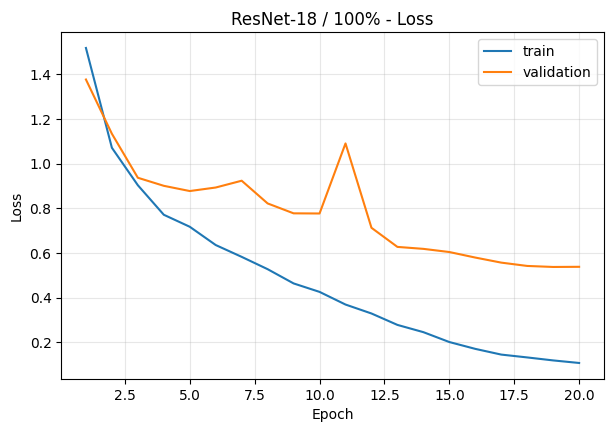

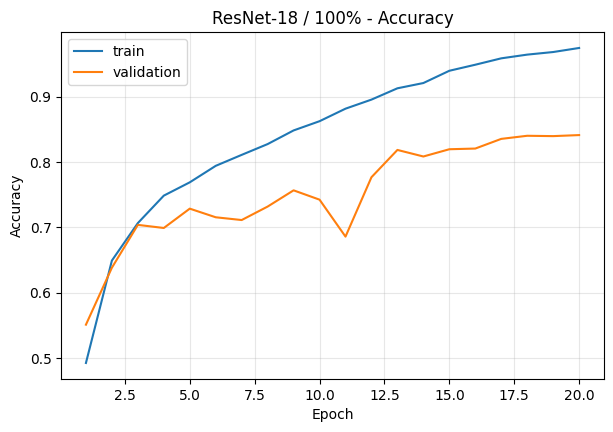

In [21]:
# ── 공통 학습 설정 ──────────────────────────────────────────────
EPOCHS = 20
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05

# 모델 초기화를 동일하게 재현하기 위해 Seed를 다시 고정합니다.
torch.manual_seed(MY_SEED)

resnet18 = ResNet18(num_classes=NUM_CLASSES)

# ResNet과 ViT가 같은 Seed에서 Shuffle을 시작하도록
# 모델별로 Train DataLoader를 새로 생성합니다.
resnet_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    generator=torch.Generator().manual_seed(MY_SEED),
)

resnet18, hist_resnet_100, summary_resnet_100 = train_model(
    model=resnet18,
    train_loader=resnet_train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    model_name="ResNet-18 / 100%",
)

plot_history(hist_resnet_100, "ResNet-18 / 100%")

### Q.3.2 ResNet 학습 결과를 확인해봅시다.

1. ResNet-18의 Best Validation Accuracy와 해당 Epoch를 적어주세요.

    A. Best val acc = 0.8411이고, epoch는 20이다.

2. 학습은 안정적인 것 같나요? 그렇게 생각한 이유를 적어주세요.

    A. 안정적이지 않은 것 같아용... 왜냐하면 train 데이터 성능은 지속적으로 상승하지만 Validation Loss는 15 Epoch 이후 정체되고 11 Epoch 부근에서 손실값이 급격히 튀는 불안정성을 보이기 때문이다.

---

# 4. Vision Transformer 직접 구현하기

두 번째 모델은 **Vision Transformer(ViT)** 입니다.

ViT는 이미지를 CNN처럼 작은 Convolution Kernel로 반복 처리하는 대신, 이미지를 일정한 크기의 **Patch**로 나누어 하나의 Token Sequence로 바꾼 뒤 Transformer Encoder에 입력합니다.

이번 과제에서는 Transformer의 Attention 수식 전체를 바닥부터 구현하지는 않습니다.  
PyTorch가 제공하는 `nn.MultiheadAttention`을 사용하되, ViT의 전체 구조는 직접 구성해봅시다.

직접 구현할 요소는 다음과 같습니다.

1. **Patch Embedding**
2. **CLS Token**
3. **Positional Embedding**
4. **Transformer Encoder Block**
5. **MLP Head**

먼저 이미지를 Patch Token으로 바꾸는 과정부터 구현해봅시다.

---
## 4.1 Patch Embedding

입력 이미지 크기가 `224 × 224`, Patch 크기가 `16 × 16`이라면 한 변에 14개의 Patch가 생깁니다.

따라서 전체 Patch 수는

\[
14 x 14 = 196
\]

개입니다.

각 Patch를 직접 잘라서 Flatten할 수도 있지만, `kernel_size = stride = patch_size`인 `Conv2d`를 사용하면 **겹치지 않는 Patch 분할과 Linear Projection을 한 번에 구현**할 수 있습니다.


**코드 빈칸을 채워주세요!**

In [11]:
# ── ViT Patch Embedding ─────────────────────────────────────────
class PatchEmbedding(nn.Module):
    """
    (B, 3, H, W) 이미지를
    (B, N, D) Patch Token Sequence로 변환합니다.

    N = Patch 개수
    D = Embedding Dimension
    """

    def __init__(
        self,
        image_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=192,
    ):
        super().__init__()

        assert image_size % patch_size == 0, \
            "Image Size는 Patch Size로 나누어 떨어져야 합니다."

        self.image_size = image_size
        self.patch_size = patch_size

        patches_per_side = image_size // patch_size     # TODO
        self.num_patches = patches_per_side ** 2        # TODO

        # kernel_size와 stride를 Patch Size와 같게 설정하면
        # 서로 겹치지 않는 Patch를 만들면서 각 Patch를 embed_dim 차원으로 Projection할 수 있습니다.
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,               # TODO
            stride=patch_size,                    # TODO
        )

    def forward(self, x):
        # 입력: (B, 3, 224, 224)
        x = self.proj(x)

        # 예: (B, 192, 14, 14)
        # Spatial Dimension을 펼쳐 (B, 192, 196)으로 만듭니다.
        x = x.flatten(2)

        # Transformer는 Token Dimension이 두 번째 축에 오도록
        # (B, 196, 192) 형태로 바꿉니다.
        x = x.transpose(1, 2)

        return x

In [12]:
# ── Patch Embedding Shape 확인 ──────────────────────────────────
PATCH_SIZE = 16
EMBED_DIM = 192

patch_embed = PatchEmbedding(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
)

dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

with torch.no_grad():
    patch_tokens = patch_embed(dummy)

print("Input image shape :", dummy.shape)
print("Patch token shape :", patch_tokens.shape)
print("Number of patches :", patch_embed.num_patches)
print("Embedding dim     :", EMBED_DIM)

Input image shape : torch.Size([2, 3, 224, 224])
Patch token shape : torch.Size([2, 196, 192])
Number of patches : 196
Embedding dim     : 192


### Q.4.1 Patch를 Token으로 바꾸는 과정을 확인해봅시다.

1. 실제 `patch_tokens.shape`를 적고 각 차원이 무엇을 의미하는지 설명해주세요.

    A. Patch token shape : torch.Size([2, 196, 192])이다. 배치 크기가 2, 이미지 한 장당의 패치 개수가 196개, 패치별 임베딩한 차원의 개수가 192개이다.

2. Patch Size를 `32×32`로 키운다면 Token 수는 몇 개로 줄어드나요?

    A. image size가 224이므로 patch size로 나누면 7개이므로 token 수가 7 x 7 = 49개로 줄어들게 된다.

3. Token 수가 줄어들면 Self-Attention의 계산량은 일반적으로 어떤 방향으로 변할까요?

    A. 계산량이 적어질 것 같다. 왜냐하면 patch를 token으로 바꾸는 과정의 수가 적어진다면 애초에 수치 자체도 작어질 것이기 때문이다.

---
## 4.2 Transformer Encoder와 ViT 전체 구조

Patch Token만 Transformer에 넣으면 각 Token이 원래 이미지의 어느 위치에서 왔는지 알기 어렵습니다.  
따라서 각 위치에 대응하는 **Positional Embedding**을 더해줍니다.

또한 이미지 전체를 하나의 Class로 분류해야 하므로 Patch Token 앞에 학습 가능한 **CLS Token**을 추가합니다.

결과적으로 Transformer Encoder에 들어가는 Sequence는 다음과 같습니다.

`[CLS] + Patch 1 + Patch 2 + ... + Patch 196`

즉 Sequence Length는 총 **197**입니다.

Encoder Block 내부에서는 다음 두 단계가 반복됩니다.

1. `LayerNorm → Multi-Head Self-Attention → Residual Connection`
2. `LayerNorm → MLP → Residual Connection`

이번 구현에서는 ViT에서 널리 사용되는 **Pre-Norm 구조**를 사용합니다.


**코드 빈칸을 채워주세요!!**

Encoder Block 구현할 때 구조 참고하세요!

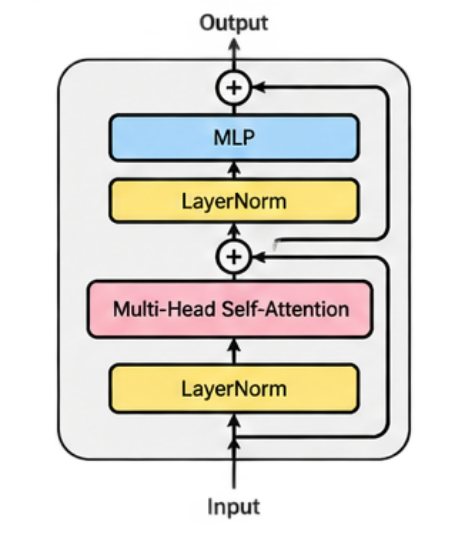

In [15]:
# ── ViT의 MLP Block ─────────────────────────────────────────────
class MLP(nn.Module):
    """Transformer Encoder 안에서 각 Token의 Feature를 변환하는 Feed-Forward Network입니다."""

    def __init__(self, embed_dim, mlp_ratio=4.0, dropout=0.1):
        super().__init__()

        hidden_dim = int(embed_dim * mlp_ratio)

        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# ── Transformer Encoder Block ───────────────────────────────────
class TransformerEncoderBlock(nn.Module):
    """
    Pre-Norm Transformer Encoder Block

    x = x + MSA(LN(x))
    x = x + MLP(LN(x))
    """

    def __init__(
        self,
        embed_dim,
        num_heads,
        mlp_ratio=4.0,
        dropout=0.1,
        attn_dropout=0.0,
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        # batch_first=True이므로 입력 Shape를 (B, N, D)로 그대로 사용할 수 있습니다.
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True,
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = MLP(
            embed_dim=embed_dim,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )

    def forward(self, x):
        # ── Multi-Head Self-Attention + Residual ────────────────
        norm_x = self.norm1(x)               # TODO : 첫번째 LayerNorm

        attn_out, _ = self.attn(
            norm_x,                           # TODO
            norm_x,                           # TODO
            norm_x,                           # TODO
            need_weights=False,
        )

        x = x + attn_out                     # TODO

        # ── MLP + Residual ─────────────────────────────────────
        x = x + self.mlp(self.norm2(x))   # TODO

        return x

**여기도 빈칸 많아요**

In [16]:
# ── Vision Transformer 전체 Architecture ────────────────────────
class VisionTransformer(nn.Module):
    """
    교육용 ViT-Tiny 스타일 모델

    Image
      -> Patch Embedding
      -> [CLS] Token 추가
      -> Positional Embedding 추가
      -> Transformer Encoder Blocks
      -> Final LayerNorm
      -> CLS Token
      -> Linear Classification Head

    기본 설정:
      Image Size = 224
      Patch Size = 16
      Embedding Dim = 192
      Depth = 12
      Heads = 3
    """

    def __init__(
        self,
        image_size=224,
        patch_size=16,
        num_classes=10,
        embed_dim=192,
        depth=12,
        num_heads=3,
        mlp_ratio=4.0,
        dropout=0.1,
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=3,
            embed_dim=embed_dim,
        )

        num_patches = self.patch_embed.num_patches

        # CLS Token은 이미지에서 직접 잘라낸 Patch가 아니라
        # 학습되는 하나의 Parameter입니다.

        # PyTorch에서 토큰 데이터는 기본적으로 (Batch Size, Sequence Length, Embedding Dimension) 형태의 3차원 모양을 가진다...!
        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, embed_dim)                # TODO
        )

        # CLS 위치까지 포함하므로 길이는??
        # num_patches + 1이 되는 이유는 Positional Embedding이 'CLS 토큰'을 포함한 전체 토큰 위치에 각각 더해져야 하기 때문이다..!
        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim)    #TODO
        )

        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        # 최종 CLS Token의 Feature를 Class Logit으로 변환합니다.
        self.head = nn.Linear(embed_dim, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        # CLS Token과 Positional Embedding은 작은 값에서 시작합니다.
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Linear / LayerNorm도 Transformer에서 흔히 사용하는 방식으로 초기화합니다.
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)

                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)

            elif isinstance(module, nn.LayerNorm):
                nn.init.constant_(module.weight, 1.0)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        batch_size = x.size(0)

        # ── 1. Image -> Patch Tokens ────────────────────────────
        x = self.patch_embed(x)                # TODO
        # Shape: (B, 196, D)

        # ── 2. CLS Token 추가 ──────────────────────────────────
        cls_tokens = self.cls_token.expand(
            batch_size, -1, -1
        )

        x = torch.cat(
            [cls_tokens, x],               # TODO
            dim=1,
        )
        # Shape: (B, 197, D)

        # ── 3. Positional Embedding 추가 ───────────────────────
        # Concatenation이 아니라 Element-wise Addition입니다.
        x = x + self.pos_embed            # TODO
        x = self.pos_drop(x)

        # ── 4. Transformer Encoder ─────────────────────────────
        for block in self.blocks:
            x = block(x)                 # TODO: 블록을 통과한다는 코드의 뜻...!

        x = self.norm(x)

        # ── 5. CLS Token만 Classification Head로 전달 ──────────
        cls_feature = x[:, 0]        # TODO: cls token이 맨 앞에 있으니까 인덱스 0에 해당함...!

        logits = self.head(cls_feature)
        return logits

In [17]:
# ── ViT 구조가 정상적으로 동작하는지 확인 ──────────────────────
torch.manual_seed(MY_SEED)

vit = VisionTransformer(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES,
    embed_dim=192,
    depth=12,
    num_heads=3,
    mlp_ratio=4.0,
    dropout=0.1,
)

dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

with torch.no_grad():
    dummy_output = vit(dummy)

print(vit)
print("\nViT output shape      :", dummy_output.shape)
print("Trainable parameters :", f"{count_parameters(vit):,}")
print("Positional Embedding :", tuple(vit.pos_embed.shape))

assert dummy_output.shape == (2, NUM_CLASSES)

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x TransformerEncoderBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (net): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=768, out_features=192, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=192, out_features=10, bias=True)
)

ViT output shape      

### Q.4.2 ViT 구조를 코드와 연결해봅시다.

1. CLS Token과 Positional Embedding은 각각 어떤 역할을 하나요?

    A. CLS Token은 클래스를 분류하는 역할을 하고, Positional Embedding은 각 토큰이 이미지의 어느 위치에 존재하는지 알려주는 역할을 한다.

2. CNN에서는 Layer가 깊어지면서 Receptive Field가 점차 넓어집니다. 반면 기본 ViT에서는 첫 번째 Encoder Block부터 멀리 떨어진 Patch 간 관계를 직접 학습할 수 있는 이유는 무엇인가요?

    A. self-attention으로 모든 토큰들과의 연관성을 다 알아낼 수 있기 때문이다. 그래서 멀리 떨어진 patch 간의 관계를 직접 학습할 수 있게 된다.


---
## 4.3 ViT를 Imagenette 100%로 학습해봅시다.

이제 직접 구현한 ViT를 ResNet과 **동일한 데이터와 동일한 Training Pipeline**으로 학습합니다.

ViT만을 위해 별도의 더 좋은 Hyperparameter를 찾지 않고, 앞에서 ResNet에 사용했던 조건을 그대로 사용합니다.  
따라서 이번 결과는 각 모델의 최고 성능을 겨루는 Benchmark라기보다, **동일 조건에서 두 Architecture의 학습 특성을 비교하는 실험**으로 해석해야 합니다.

아마 ResNet보다 정확도가 낮을텐데 정상인거니 재실행 안하셔도 됩니다!

이번 학습도 시간이 오래걸립니다! (저는 30-40분 정도 걸렸습니다)

[ViT / 100%] Epoch 01/20 | train loss 2.0456 acc 0.2627 | val loss 1.9048 acc 0.3284 | lr 3.00e-04
[ViT / 100%] Epoch 02/20 | train loss 1.7676 acc 0.3848 | val loss 1.6550 acc 0.4562 | lr 2.98e-04
[ViT / 100%] Epoch 03/20 | train loss 1.5685 acc 0.4690 | val loss 1.4788 acc 0.5074 | lr 2.93e-04
[ViT / 100%] Epoch 04/20 | train loss 1.4312 acc 0.5200 | val loss 1.4163 acc 0.5396 | lr 2.84e-04
[ViT / 100%] Epoch 05/20 | train loss 1.3281 acc 0.5527 | val loss 1.3741 acc 0.5375 | lr 2.71e-04
[ViT / 100%] Epoch 06/20 | train loss 1.2630 acc 0.5802 | val loss 1.2472 acc 0.5945 | lr 2.56e-04
[ViT / 100%] Epoch 07/20 | train loss 1.1773 acc 0.6040 | val loss 1.2805 acc 0.5803 | lr 2.38e-04
[ViT / 100%] Epoch 08/20 | train loss 1.1517 acc 0.6189 | val loss 1.2126 acc 0.5982 | lr 2.18e-04
[ViT / 100%] Epoch 09/20 | train loss 1.0748 acc 0.6448 | val loss 1.1258 acc 0.6346 | lr 1.96e-04
[ViT / 100%] Epoch 10/20 | train loss 1.0206 acc 0.6611 | val loss 1.1227 acc 0.6309 | lr 1.73e-04
[ViT / 100

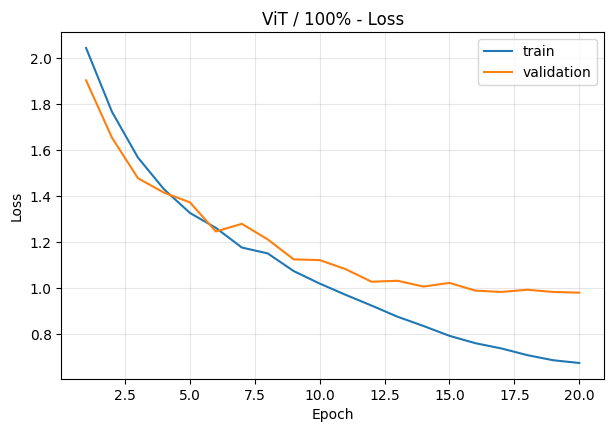

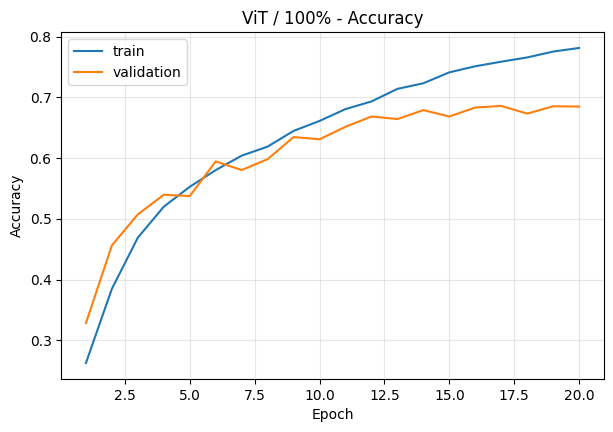

In [22]:
# ── ViT 100% 학습 ───────────────────────────────────────────────
torch.manual_seed(MY_SEED)

vit = VisionTransformer(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES,
    embed_dim=192,
    depth=12,
    num_heads=3,
    mlp_ratio=4.0,
    dropout=0.1,
)

# ResNet과 동일한 Seed에서 Shuffle을 다시 시작합니다.
vit_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    generator=torch.Generator().manual_seed(MY_SEED),
)

vit, hist_vit_100, summary_vit_100 = train_model(
    model=vit,
    train_loader=vit_train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    model_name="ViT / 100%",
)

plot_history(hist_vit_100, "ViT / 100%")

### Q.4.3 ViT 학습 결과를 확인해봅시다.

1. ViT의 Best Validation Accuracy와 해당 Epoch를 적어주세요.

    A. Best val acc = 0.6859이고, epoch 17이다.

2. 학습은 안정적인 것 같나요? 그렇게 생각한 이유를 설명해주세요.

    A. 비교적 안정적인 것 같아용... 왜냐하면 Train 곡선과 Validation 곡선이 큰 변화 없이 매끄럽게 감소 및 상승하고 있기 때문이다.


3. ResNet과 ViT 중 어떤 모델이 더 빠르게 높은 Validation Accuracy에 도달했나요? 왜 그런 결과가 나왔다고 생각하나요?
  
    A. ResNet-18 모델이 더 빠르게 높은 Validation Accuracy에 도달했다. ResNet은 강한 합성곱 구조를 가졌기 때문이다.

---
# 5. ResNet-18 vs ViT — 100% Dataset 기본 비교

두 모델의 첫 번째 학습이 끝났습니다.

이제 동일한 100% Train Dataset에서 얻은 결과를 한 표에 모아봅시다.

여기서 비교할 값은 다음과 같습니다.

- Parameter 수
- Best Validation Accuracy
- Best Epoch
- Epoch당 학습 시간

아직 **Test set은 사용하지 않습니다.**


**여기부터는 코드 빈칸 없습니다!**

In [23]:
# ── 100% Dataset 결과 요약 ─────────────────────────────────────
comparison_100 = pd.DataFrame([
    {
        "Model": "ResNet-18",
        "Parameters": count_parameters(resnet18),
        "Best Val Acc": summary_resnet_100["best_val_acc"],
        "Best Epoch": summary_resnet_100["best_epoch"],
        "Sec / Epoch": summary_resnet_100["sec_per_epoch"],
    },
    {
        "Model": "ViT",
        "Parameters": count_parameters(vit),
        "Best Val Acc": summary_vit_100["best_val_acc"],
        "Best Epoch": summary_vit_100["best_epoch"],
        "Sec / Epoch": summary_vit_100["sec_per_epoch"],
    },
])

comparison_100

,Model,Parameters,Best Val Acc,Best Epoch,Sec / Epoch
0,ResNet-18,11181642,0.841077,20,44.930298
1,ViT,5526346,0.685850,17,48.048725


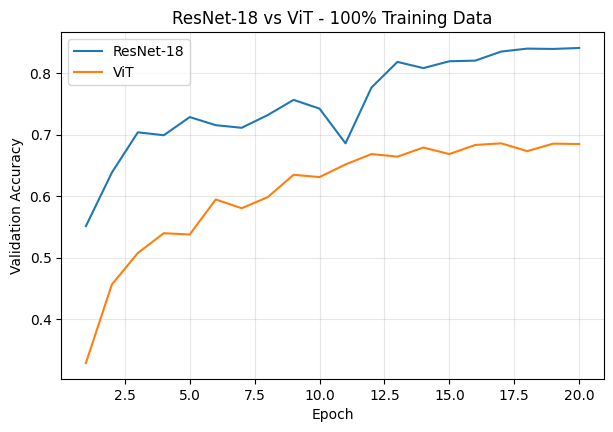

In [24]:
# ── 두 모델의 Validation Accuracy Curve를 한 그래프에서 비교 ───
epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(7, 4.5))
plt.plot(
    epochs,
    hist_resnet_100["val_acc"],
    label="ResNet-18",
)
plt.plot(
    epochs,
    hist_vit_100["val_acc"],
    label="ViT",
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ResNet-18 vs ViT - 100% Training Data")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Q.5 첫 번째 모델 비교

1. 현재 결과만으로 “ResNet이 ViT보다 좋은 모델이다” 혹은 그 반대라고 결론 내리기 어려운 이유를 적어주세요.

    A. 첨부된 그래프에서 ResNet-18의 정확도가 더 높게 나왔다. 심지어 사전학습 없이 제한된 데이터셋에서 처음부터 학습시킨 결과이고 대규모 데이터 사전 학습 환경에서 강점을 보이는 ViT의 성능이 정당하게 평가되었다고 보기 어렵기 때문이다.


2. 이번 비교에서는 두 모델에 같은 Optimizer와 Learning Rate를 사용했습니다. 이것의 **장점**과 **한계**를 각각 하나씩 설명해주세요.

    A. 장점: 두 모델의 최적화 파라미터를 통제함으로써 모델 자체의 구조적 특징에 따른 초기 수렴 속도와 성능 차이를 직접적으로 비교할 수 있다.   
    한계: 두 모델에 대해 적합한 최적의 Optimizer와 Learning Rate이 서로 다르기 때문에 동일한 설정이 특정 모델에게 불리하게 작용했을 수 있다.

---
# 6. Training Data Size를 바꾸어 비교해봅시다.

이제 이번 과제의 핵심 비교 실험을 진행합니다.

강의에서는 CNN이 이미지에 대해 다음과 같은 강한 **Inductive Bias**를 갖는다고 배웠습니다.

- Locality: 가까운 Pixel 사이의 관계를 우선적으로 처리
- Weight Sharing: 같은 Convolution Filter를 이미지 전체 위치에 반복 적용
- 계층적으로 Local Feature에서 Global Feature로 확장

반면 기본 ViT는 이러한 이미지 전용 구조적 가정이 상대적으로 약하고, Self-Attention으로 Patch 사이의 관계를 학습합니다.

그렇다면 학습 데이터가 충분하지 않을 때 두 모델은 어떤 차이를 보일까요?

이번에는 같은 Train split에서 **10% / 30% / 100%**만 사용해 두 모델을 각각 처음부터 다시 학습합니다.

> **주의:** 100% 결과는 이미 §3과 §4에서 얻었으므로 다시 학습하지 않고 그대로 재사용합니다.

이번 코드는 총합 20-30분 정도 걸릴겁니다!

### Q.6.1 코드를 실행하기 전에 먼저 예상해봅시다.

아래 질문은 **다음 코드 셀을 실행하기 전에** 답해주세요.

1. Training Data가 `100% → 30% → 10%`로 줄어들 때 ResNet과 ViT 중 어느 모델의 성능 하락폭이 더 클 것이라고 예상하나요?

    A. 뭔가 ResNet이 클 것 같다... 왜냐하면 강한 합성곱이 존재하기 때문이다.

2. 위 예측의 근거를 **CNN의 Inductive Bias**와 연결하여 설명해주세요.

    A.Locality로 인해서 가까운 pixel 사이의 관계를 우선적으로 처리가 가능하니까 하락폭도 그만큼 클 것 같다.



In [25]:
# ── 특정 비율의 Train Data를 Stratified Sampling하는 함수 ──────
def make_fraction_indices(base_indices, all_targets, fraction, seed):
    """
    기존 Train Index에서 지정한 비율만큼 샘플링합니다.

    stratify를 사용하여 10%나 30%만 뽑더라도
    10개 클래스의 비율이 최대한 유지되도록 합니다.
    """
    base_indices = np.asarray(base_indices)

    if fraction >= 1.0:
        return base_indices.copy()

    base_targets = np.asarray(all_targets)[base_indices]

    sampled_indices, _ = train_test_split(
        base_indices,
        train_size=fraction,
        random_state=seed,
        stratify=base_targets,
    )

    return np.asarray(sampled_indices)


def make_train_loader(indices, seed):
    """주어진 Train Index로 새로운 DataLoader를 만듭니다."""
    dataset = Subset(
        train_aug_dataset,
        indices,
    )

    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        generator=generator,
    )


# 실제 각 비율에서 몇 장이 사용되는지 먼저 확인합니다.
fractions = [0.10, 0.30, 1.00]

for frac in fractions:
    idx = make_fraction_indices(
        train_indices,
        train_targets,
        fraction=frac,
        seed=MY_SEED,
    )
    print(f"{frac:>4.0%} -> {len(idx):5d} training images")

 10% ->   757 training images
 30% ->  2272 training images
100% ->  7575 training images


In [26]:
# ── Data Size Experiment ────────────────────────────────────────
# 100% 결과는 이미 학습했으므로 재사용하고,
# 10% / 30% 조건만 새롭게 학습합니다.

data_size_results = []

# 먼저 100% 결과를 기록합니다.
data_size_results.extend([
    {
        "Model": "ResNet-18",
        "Fraction": 1.00,
        "Train Images": len(train_indices),
        "Best Val Acc": summary_resnet_100["best_val_acc"],
        "Best Epoch": summary_resnet_100["best_epoch"],
        "Sec / Epoch": summary_resnet_100["sec_per_epoch"],
    },
    {
        "Model": "ViT",
        "Fraction": 1.00,
        "Train Images": len(train_indices),
        "Best Val Acc": summary_vit_100["best_val_acc"],
        "Best Epoch": summary_vit_100["best_epoch"],
        "Sec / Epoch": summary_vit_100["sec_per_epoch"],
    },
])

# ── 10% / 30% 조건을 차례대로 학습 ─────────────────────────────
for fraction in [0.10, 0.30]:

    subset_indices = make_fraction_indices(
        train_indices,
        train_targets,
        fraction=fraction,
        seed=MY_SEED,
    )

    print("\n" + "=" * 80)
    print(
        f"Training Data = {fraction:.0%} "
        f"({len(subset_indices)} images)"
    )
    print("=" * 80)

    # ── ResNet-18 ───────────────────────────────────────────────
    # 매 실험마다 반드시 새 모델을 만들어 Random Initialization부터 다시 시작합니다.
    torch.manual_seed(MY_SEED)

    resnet_tmp = ResNet18(
        num_classes=NUM_CLASSES
    )

    fraction_loader_resnet = make_train_loader(
        subset_indices,
        seed=MY_SEED,
    )

    resnet_tmp, hist_resnet_tmp, summary_resnet_tmp = train_model(
        model=resnet_tmp,
        train_loader=fraction_loader_resnet,
        val_loader=val_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        model_name=f"ResNet-18 / {fraction:.0%}",
    )

    data_size_results.append({
        "Model": "ResNet-18",
        "Fraction": fraction,
        "Train Images": len(subset_indices),
        "Best Val Acc": summary_resnet_tmp["best_val_acc"],
        "Best Epoch": summary_resnet_tmp["best_epoch"],
        "Sec / Epoch": summary_resnet_tmp["sec_per_epoch"],
    })

    del resnet_tmp
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    # ── ViT ─────────────────────────────────────────────────────
    torch.manual_seed(MY_SEED)

    vit_tmp = VisionTransformer(
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        num_classes=NUM_CLASSES,
        embed_dim=192,
        depth=12,
        num_heads=3,
        mlp_ratio=4.0,
        dropout=0.1,
    )

    fraction_loader_vit = make_train_loader(
        subset_indices,
        seed=MY_SEED,
    )

    vit_tmp, hist_vit_tmp, summary_vit_tmp = train_model(
        model=vit_tmp,
        train_loader=fraction_loader_vit,
        val_loader=val_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        model_name=f"ViT / {fraction:.0%}",
    )

    data_size_results.append({
        "Model": "ViT",
        "Fraction": fraction,
        "Train Images": len(subset_indices),
        "Best Val Acc": summary_vit_tmp["best_val_acc"],
        "Best Epoch": summary_vit_tmp["best_epoch"],
        "Sec / Epoch": summary_vit_tmp["sec_per_epoch"],
    })

    del vit_tmp
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


Training Data = 10% (757 images)
[ResNet-18 / 10%] Epoch 01/20 | train loss 2.1192 acc 0.2642 | val loss 2.9173 acc 0.1758 | lr 3.00e-04
[ResNet-18 / 10%] Epoch 02/20 | train loss 1.6606 acc 0.4095 | val loss 2.4233 acc 0.2788 | lr 2.98e-04
[ResNet-18 / 10%] Epoch 03/20 | train loss 1.4602 acc 0.4742 | val loss 2.9464 acc 0.3131 | lr 2.93e-04
[ResNet-18 / 10%] Epoch 04/20 | train loss 1.2923 acc 0.5548 | val loss 1.9342 acc 0.4108 | lr 2.84e-04
[ResNet-18 / 10%] Epoch 05/20 | train loss 1.1733 acc 0.5918 | val loss 2.5350 acc 0.3564 | lr 2.71e-04
[ResNet-18 / 10%] Epoch 06/20 | train loss 1.0214 acc 0.6526 | val loss 1.6595 acc 0.5016 | lr 2.56e-04
[ResNet-18 / 10%] Epoch 07/20 | train loss 0.8957 acc 0.6790 | val loss 1.6563 acc 0.4952 | lr 2.38e-04
[ResNet-18 / 10%] Epoch 08/20 | train loss 0.7648 acc 0.7569 | val loss 1.4513 acc 0.5475 | lr 2.18e-04
[ResNet-18 / 10%] Epoch 09/20 | train loss 0.6249 acc 0.7992 | val loss 1.4015 acc 0.5755 | lr 1.96e-04
[ResNet-18 / 10%] Epoch 10/20 

In [27]:
# ── Data Size Experiment 결과표 ─────────────────────────────────
data_size_df = pd.DataFrame(data_size_results)

data_size_df = data_size_df.sort_values(
    ["Model", "Fraction"]
).reset_index(drop=True)

data_size_df

,Model,Fraction,Train Images,Best Val Acc,Best Epoch,Sec / Epoch
0,ResNet-18,0.1,757,0.620908,19,12.521189
1,ResNet-18,0.3,2272,0.736536,20,19.652507
2,ResNet-18,1.0,7575,0.841077,20,44.930298
3,ViT,0.1,757,0.429250,20,13.067351
4,ViT,0.3,2272,0.574446,18,20.852338
5,ViT,1.0,7575,0.685850,17,48.048725


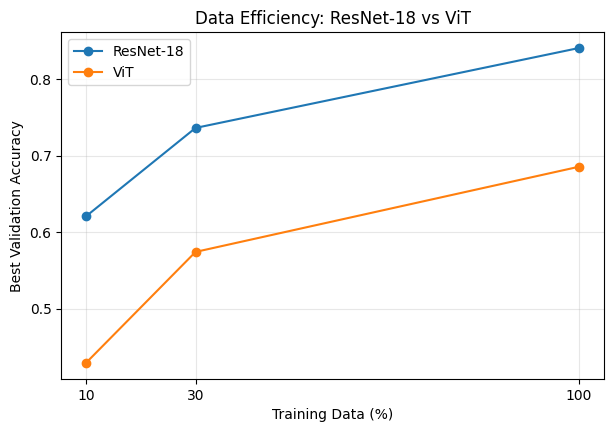

In [28]:
# ── Training Data 비율에 따른 Validation Accuracy 변화 ─────────
plt.figure(figsize=(7, 4.5))

for model_name in ["ResNet-18", "ViT"]:
    temp = data_size_df[
        data_size_df["Model"] == model_name
    ].sort_values("Fraction")

    plt.plot(
        temp["Fraction"] * 100,
        temp["Best Val Acc"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Training Data (%)")
plt.ylabel("Best Validation Accuracy")
plt.title("Data Efficiency: ResNet-18 vs ViT")
plt.xticks([10, 30, 100])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [29]:
# ── 10% -> 100%에서 Accuracy가 얼마나 변했는지 계산 ────────────
pivot_acc = data_size_df.pivot(
    index="Fraction",
    columns="Model",
    values="Best Val Acc",
).sort_index()

print(pivot_acc)

print("\n[Accuracy change: 10% -> 100%]")
for model_name in ["ResNet-18", "ViT"]:
    acc_10 = pivot_acc.loc[0.10, model_name]
    acc_100 = pivot_acc.loc[1.00, model_name]
    change = acc_100 - acc_10

    print(
        f"{model_name:10s}: "
        f"{acc_10:.4f} -> {acc_100:.4f} "
        f"(+{change:.4f}, {change*100:.2f}%p)"
    )

Model     ResNet-18       ViT
Fraction                     
0.1        0.620908  0.429250
0.3        0.736536  0.574446
1.0        0.841077  0.685850

[Accuracy change: 10% -> 100%]
ResNet-18 : 0.6209 -> 0.8411 (+0.2202, 22.02%p)
ViT       : 0.4293 -> 0.6859 (+0.2566, 25.66%p)


### Q.6.2 실제 결과를 바탕으로 판단해봅시다.

1. 10%, 30%, 100%에서 ResNet-18과 ViT의 Best Validation Accuracy를 모두 적어주세요.

    A. [ResNet-18 / 10%] Best val acc = 0.6209 (epoch 19), [ViT / 10%] Best val acc = 0.4293 (epoch 20), [ResNet-18 / 30%] Best val acc = 0.7365 (epoch 20), [ViT / 30%] Best val acc = 0.5744 (epoch 18)

2. 각 모델에서 `10% → 100%`로 데이터가 증가했을 때 Accuracy가 몇 %p 증가했나요?

    A.ResNet-18 : 0.6209 -> 0.8411 (+0.2202, 22.02%p), ViT: 0.4293 -> 0.6859 (+0.2566, 25.66%p)

3. Q.6.1에서 작성한 본인의 사전 예측과 실제 결과가 일치했나요?

    A. 틀렸습니다...ㅠ

4. ResNet은 Convolution을 통해 Local Feature를 계층적으로 학습하고, ViT는 Patch Token 사이의 Self-Attention을 사용합니다. 이러한 구조 차이가 학습 데이터의 양에 따른 성능 변화와 어떤 관계가 있다고 생각하나요?

    A. ResNet은 합성곱 구조의 강한 inductive bias 덕분에 적은 데이터로도 빠르게 높은 성능을 낸다. 반면 ViT는 패치 토큰 간의 Self-Attention으로 공간 관계를 처음부터 학습해야 하므로 적은 데이터에서는 불리하지만 데이터가 많아질수록 사전 편향을 넘어 더 뛰어난 성능을 발휘한다.


---
# 7. 마지막으로 Test Set을 확인해봅시다.

지금까지 모델 비교와 Data Size 실험은 Validation Set을 기준으로 진행했습니다.

이제 모든 비교가 끝났으므로, **100% Dataset에서 학습한 ResNet-18과 ViT의 Best Weight**를 Test Set에서 평가해봅시다.

Test Set은 최종 성적표에 해당합니다.  
만약 Test Accuracy를 반복해서 확인하면서 Hyperparameter를 바꾼다면 Test Set도 사실상 Validation Set처럼 사용하게 되므로, 최종 일반화 성능을 정직하게 측정하기 어려워집니다.

In [30]:
# ── 최종 Test Evaluation ────────────────────────────────────────
resnet_test_loss, resnet_test_acc = evaluate(
    resnet18,
    test_loader,
    DEVICE,
)

vit_test_loss, vit_test_acc = evaluate(
    vit,
    test_loader,
    DEVICE,
)

final_test_df = pd.DataFrame([
    {
        "Model": "ResNet-18",
        "Best Val Acc": summary_resnet_100["best_val_acc"],
        "Test Loss": resnet_test_loss,
        "Test Acc": resnet_test_acc,
    },
    {
        "Model": "ViT",
        "Best Val Acc": summary_vit_100["best_val_acc"],
        "Test Loss": vit_test_loss,
        "Test Acc": vit_test_acc,
    },
])

final_test_df

,Model,Best Val Acc,Test Loss,Test Acc
0,ResNet-18,0.841077,0.521785,0.840510
1,ViT,0.685850,0.952054,0.695032


In [31]:
# ── Class별 Test Accuracy도 함께 확인 ───────────────────────────
@torch.no_grad()
def per_class_accuracy(model, loader, device, num_classes):
    """각 Class별 정답 수 / 전체 수를 계산합니다."""
    model.eval()

    correct = np.zeros(num_classes, dtype=np.int64)
    total = np.zeros(num_classes, dtype=np.int64)

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)

        for c in range(num_classes):
            mask = labels == c
            total[c] += mask.sum().item()
            correct[c] += ((preds == labels) & mask).sum().item()

    return correct / total


resnet_class_acc = per_class_accuracy(
    resnet18, test_loader, DEVICE, NUM_CLASSES
)

vit_class_acc = per_class_accuracy(
    vit, test_loader, DEVICE, NUM_CLASSES
)

class_result_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "ResNet-18": resnet_class_acc,
    "ViT": vit_class_acc,
})

class_result_df

,Class,ResNet-18,ViT
0,tench,0.912145,0.782946
1,English springer,0.911392,0.767089
2,cassette player,0.857143,0.697479
3,chain saw,0.759067,0.559585
4,church,0.848411,0.689487
5,French horn,0.822335,0.748731
6,garbage truck,0.856041,0.694087
7,gas pump,0.739857,0.589499
8,golf ball,0.832080,0.639098
9,parachute,0.874359,0.789744


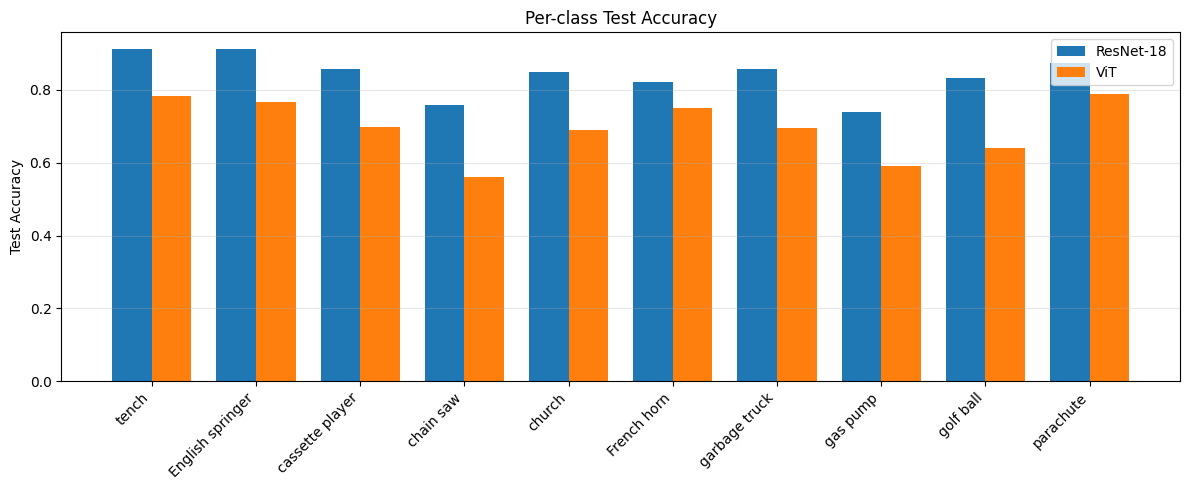

In [32]:
# ── Class별 성능 비교 그래프 ────────────────────────────────────
x = np.arange(NUM_CLASSES)
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(
    x - width / 2,
    resnet_class_acc,
    width,
    label="ResNet-18",
)
plt.bar(
    x + width / 2,
    vit_class_acc,
    width,
    label="ViT",
)

plt.xticks(
    x,
    CLASS_NAMES,
    rotation=45,
    ha="right",
)
plt.ylabel("Test Accuracy")
plt.title("Per-class Test Accuracy")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Q.7 최종 서술형

1. 이번 실험에서 관찰한 ResNet과 ViT의 학습 특성 차이를 Data Size Experiment의 실제 결과를 근거로 설명해주세요.

    A. ResNet은 데이터 크기가 작아도 합성곱 특유의 공간적 사전 편향 덕분에 안정한 성능을 내는 반면, ViT는 셀프 어텐션의 특성상 적은 데이터셋에서 학습 불안정성이 크게 나타난다.

2. Imagenette보다 훨씬 큰 Dataset에서 충분히 학습한다면 두 모델의 격차가 어떻게 변할 것으로 예상하나요?

    A. 방대한 데이터셋에서는 공간적 사전 편향의 제약이 사라진 ViT가 데이터의 전체적인 관계를 더 깊이 학습하여 ResNet의 성능을 앞지를 것이다.


---

## Q.8 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (pytorch 문법 설명, 더 구체적으로 과제 질문을 물어봄)

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (딱히 없었습니다.)

- **실제 대화 내역** 붙여넣기:

```
(1. token 수가 적어지면 계산량이 줄어드는건 알겠는데 왜 줄어드는건지 구체적으로 알려줘.
1. Self-Attention은 모든 토큰이 서로의 연관성을 계산해야 하므로 연산량이 토큰 수의 제곱($O(N^2)$)에 비례하여 늘어납니다. 따라서 패치 크기가 커져 토큰 수가 $4$분의 $1$로 줄어들면, Self-Attention 연산량은 그 제곱 비율인 $16$분의 $1$ 수준으로 급격하게 감소합니다. 결과적으로 토큰 수가 줄어들수록 모델의 전반적인 계산 비용과 메모리 사용량이 크게 절감됩니다.
2. ResNet과 ViT의 공간적 사전 편향(Spatial Inductive Bias) 차이Q. ResNet은 공간적 구조와 지역성을 먼저 반영하는 합성곱(Convolution) 구조의 강한 공간적 사전 편향 덕분에 적은 데이터로도 빠르게 높은 성능을 내는 반면, ViT는 패치 토큰 간 셀프 어텐션(Self-Attention)으로 공간 관계를 처음부터 학습해야 합니다. 이 둘의 구조 차이가 데이터 양에 따른 성능 변화와 어떤 관계가 있나요?A. ResNet은 공간적 사전 편향 덕분에 적은 데이터로도 효율적이고 빠르게 높은 성능에 도달할 수 있습니다. 반면 ViT는 공간적 관계를 처음부터 스스로 학습해야 하므로 적은 데이터셋에서는 불리하지만, 데이터의 양이 충분히 많아질수록 사전 편향의 한계를 넘어 ResNet보다 뛰어난 표현력과 성능을 발휘합니다.
3. ViT가 데이터가 많아질수록 더 뛰어난 성능을 발휘하는 이유Q. 왜 ViT는 데이터가 적을 때는 성능이 안 나오다가, 데이터가 많아질수록 ResNet보다 더 뛰어난 성능을 발휘하나요?A. CNN(ResNet)의 공간적 사전 편향은 데이터가 적을 땐 학습을 돕지만, 데이터가 넘칠 때는 고정된 규칙으로 작용하여 성능의 천장(한계)을 만듭니다. 반면 ViT는 이러한 구조적 제약이 없어 데이터가 충분히 공급되면 모든 패치 간의 전역적(Global) 복잡한 관계를 한계 없이 흡수하여 더 고차원적인 표현을 학습할 수 있기 때문입니다.
4. 실험 조건(동일 하이퍼파라미터 적용)의 장점과 한계
5. ResNet과 ViT 비교 실험에서 두 모델에 같은 Optimizer와 Learning Rate를 사용했을 때의 장점과 한계는 무엇인가요?
5. 장점은 파라미터를 통제함으로써 모델 자체의 구조적 특징(Convolution vs Self-Attention)에 따른 성능 차이를 직관적으로 비교할 수 있다는 점입니다. 한계는 CNN과 Transformer가 선호하는 최적 최적화 옵션(SGD vs AdamW 등)이 달라서, 동일한 설정이 특정 모델에게 불리하게 작용했을 수 있다는 점입니다.
6. 데이터 비율 실험(10%, 30%, 100%)에서 난수 시드 고정 이유Q. Data Size Experiment에서 각 데이터 비율마다 동일한 난수 시드로 모델을 새로 초기화하여 재학습을 진행한 이유는 무엇인가요?
6. 초기 가중치의 무작위성으로 인한 오차를 통제하고, 오직 데이터 양의 변화가 성능에 미치는 영향만을 독립적으로 비교하여 실험의 신뢰성과 재현성을 확보하기 위해서입니다.
7. 토큰 수 감소에 따른 ViT 연산량 변화Q. Token 수가 적어지면 계산량이 줄어드는 건 알겠는데 왜 줄어드는 건지 구체적으로 알려주세요.
7. Self-Attention은 모든 토큰이 서로의 연관성을 계산해야 하므로 연산량이 토큰 수의 제곱($O(N^2)$)에 비례하여 늘어납니다. 따라서 패치 크기가 커져 토큰 수가 $4$분의 $1$로 줄어들면, Self-Attention 연산량은 그 제곱 비율인 $16$분의 $1$ 수준으로 급격하게 감소하여 전반적인 계산 비용과 메모리 사용량이 크게 절감됩니다.)
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? (질문을 날카롭게 하고, 구조적 원인을 탐구하는 것)

___
#5주차 과제는 이상입니다. 모두 수고하셨습니다 :)